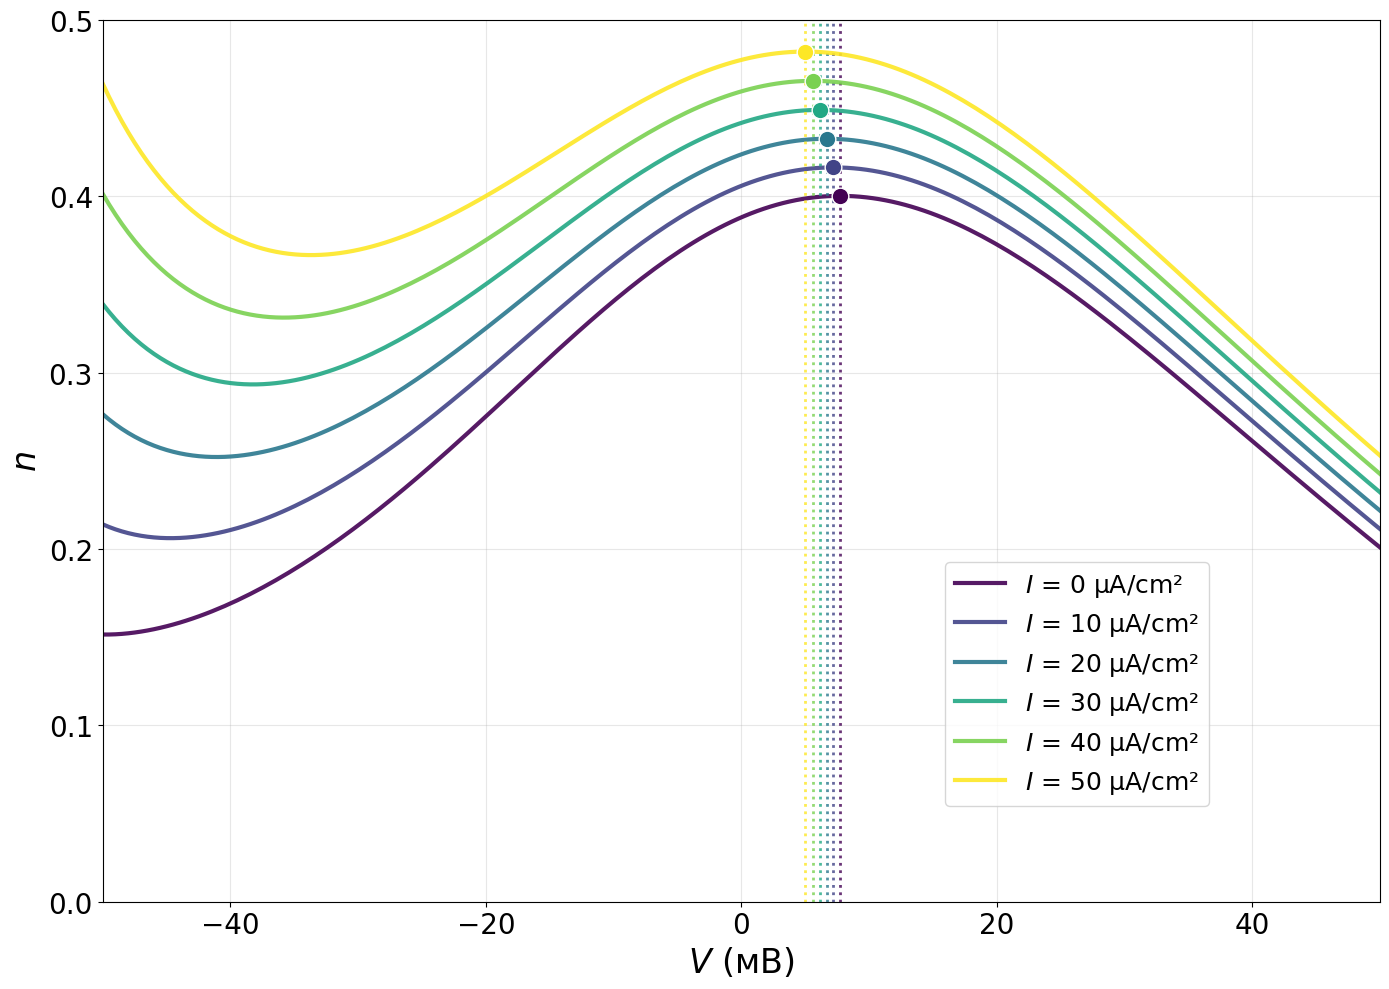


 Координаты правого колена для различных токов:
I (μA)     V_knee (мВ)     n_knee    
--------------------------------------------------
0.00       7.7             0.400     
10.00      7.2             0.416     
20.00      6.7             0.433     
30.00      6.1             0.449     
40.00      5.6             0.465     
50.00      5.0             0.482     
--------------------------------------------------


In [1]:
"""
Morris-Lecar Model: Nullclines Family and Right Knee Detection.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Модельные параметры нейрона Morris-Lecar
PARAMS = {
    'C': 20.0,
    'g_leak': 0.20,
    'V_leak': -50.0,
    'g_Ca': 4.4,
    'V_Ca': 100.0,
    'g_K': 8.0,
    'V_K': -70.0,
    'V1': -1.0,
    'V2': 15.0,
    'V3': 2.0,
    'V4': 30.0,
    'phi': 0.05
}

def inf_m(V):
    """Стационарная функция активации кальциевых каналов (m_inf)."""
    return 1 / (1 + np.exp((PARAMS['V1'] - V) / PARAMS['V2']))

def inf_n(V):
    """Стационарная функция активации калиевых каналов (n_inf)."""
    return 1 / (1 + np.exp((PARAMS['V3'] - V) / PARAMS['V4']))

def get_n_nullcline(V, I):
    """Вычисляет значение n для V-изоклины при заданном токе I."""
    m_inf = inf_m(V)
    I_leak = PARAMS['g_leak'] * (V - PARAMS['V_leak'])
    I_Ca = PARAMS['g_Ca'] * m_inf * (V - PARAMS['V_Ca'])
    denom = PARAMS['g_K'] * (V - PARAMS['V_K'])

    # Защита от деления на ноль при V == V_K
    if isinstance(V, np.ndarray):
        denom = np.where(np.abs(denom) < 1e-10, 1e-10, denom)
        return np.clip((I - I_leak - I_Ca) / denom, 0, 1)
    else:
        if abs(denom) < 1e-10:
            return 0.0
        return np.clip((I - I_leak - I_Ca) / denom, 0, 1)

def find_right_knee_V(I):
    """Находит потенциал V, соответствующий правому колену кубической изоклины."""
    def dn_dV(V):
        dV = 0.1
        return (get_n_nullcline(V + dV, I) - get_n_nullcline(V - dV, I)) / (2 * dV)

    # Поиск экстремума (где производная dn/dV равна 0)
    V_knee = fsolve(dn_dV, x0=5.0)[0]
    return V_knee

def plot_nullclines_family():
    """Строит семейство изоклин и выводит таблицу экстремумов."""
    I_values = np.linspace(0, 50.0, 6)
    V_range = np.linspace(-50, 50, 200)

    plt.figure(figsize=(14, 10))
    colors = plt.cm.viridis(np.linspace(0, 1, len(I_values)))

    # 1. Построение V-изоклин для каждого тока
    for idx, I in enumerate(I_values):
        n_values = get_n_nullcline(V_range, I)
        plt.plot(V_range, n_values, color=colors[idx], linewidth=3,
                 label=f'$I$ = {I:.0f} μA/cm²', alpha=0.9)

        # Нахождение и отметка правого колена
        V_knee = find_right_knee_V(I)
        n_knee = get_n_nullcline(V_knee, I)

        plt.axvline(V_knee, color=colors[idx], linestyle=':', linewidth=2, alpha=0.8)
        plt.plot(V_knee, n_knee, 'o', color=colors[idx], markersize=12,
                 markeredgecolor='white', zorder=10)

    # Настройка графиков
    plt.xlabel('$V$ (мВ)', fontsize=24)
    plt.ylabel('$n$', fontsize=24)
    plt.legend(bbox_to_anchor=(0.65, 0.4), loc='upper left', fontsize=18)
    plt.grid(True, alpha=0.3)
    plt.xlim(-50, 50)
    plt.ylim(0, 0.5)
    plt.gca().tick_params(axis='both', which='major', labelsize=20)
    plt.tight_layout()
    plt.show()

    # 2. Печать результатов в консоль
    print("\n" + "="*50)
    print(" Координаты правого колена для различных токов:")
    print("="*50)
    print(f"{'I (μA)':<10} {'V_knee (мВ)':<15} {'n_knee':<10}")
    print("-"*50)
    for I in I_values:
        V_knee = find_right_knee_V(I)
        n_knee_val = get_n_nullcline(V_knee, I)
        print(f"{I:<10.2f} {V_knee:<15.1f} {n_knee_val:<10.3f}")
    print("-"*50)

if __name__ == "__main__":
    plot_nullclines_family()